# Linear Regression - Practice

We will apply what you learned about linear regression for a new data set. 

The `Data` folder contains a `csv`-file containing information about CO$_2$ vehicle emissions for vehicles in Canada. 

You can now practice what you learned by 

1. loading the dataset into pandas
2. performing exploratory data analysis to understand
    - what the columns are?
    - descriptive statistics of numeric and text columns (e.g. value counts, mean, std)
3. make plots and calculate correlation coefficients to find linear correlations in the data
4. apply simple linear regression 
5. apply multiple linear regression 
6. explore the impact of the car type (a discrete variable) on CO$_2$ emissions

**Happy working!**

In [4]:
# We import all the packages that we need for this week's lab.  

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import statsmodels.formula.api as smf 
import statsmodels.api as sm 

In [11]:
df_emissions = pd.read_csv('../Data/CO2 Emissions_Canada.csv',
                          sep = ',',
                          na_values='NA',
                          #index_col=0   # Use the first column as the index of the DataFrame
                          )
df_emissions

#df_emissions.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [14]:
df_emissions.describe()
df_emissions.info()

<class 'pandas.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   str    
 1   Model                             7385 non-null   str    
 2   Vehicle Class                     7385 non-null   str    
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   str    
 6   Fuel Type                         7385 non-null   str    
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: float64(4), in

In [13]:
df_acura = df_emissions.loc[df_emissions.Make == 'ACURA']
df_acura

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
...,...,...,...,...,...,...,...,...,...,...,...,...
6508,ACURA,RDX AWD A-SPEC,SUV - SMALL,2.0,4,AS10,Z,11.3,9.1,10.3,27,241
6509,ACURA,RLX Hybrid,MID-SIZE,3.5,6,AM7,Z,8.4,8.2,8.4,34,196
6510,ACURA,TLX A-SPEC,COMPACT,2.4,4,AM8,Z,10.2,7.4,8.9,32,209
6511,ACURA,TLX SH-AWD,COMPACT,3.5,6,AS9,Z,11.4,7.7,9.8,29,228


<Axes: xlabel='Engine Size(L)', ylabel='CO2 Emissions(g/km)'>

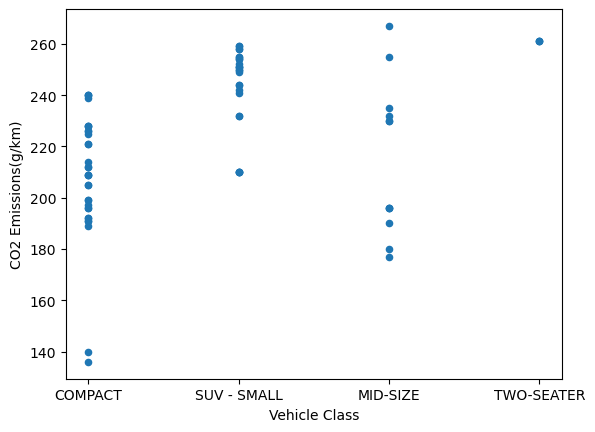

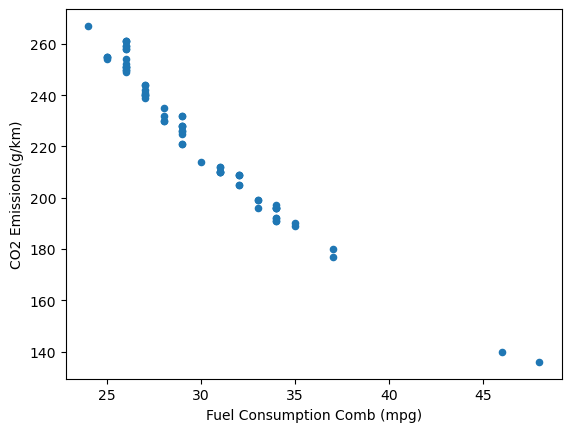

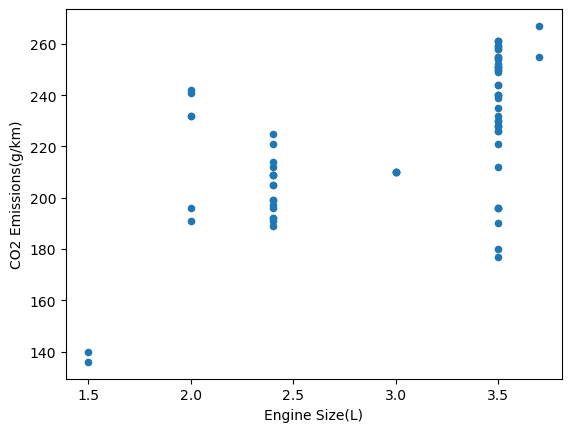

In [27]:
df_acura.plot(kind = 'scatter', x='Vehicle Class',y='CO2 Emissions(g/km)')
df_acura.plot(kind = 'scatter', x='Fuel Consumption Comb (mpg)',y='CO2 Emissions(g/km)')
df_acura.plot(kind = 'scatter', x='Engine Size(L)',y='CO2 Emissions(g/km)')

In [22]:
df_without_nan = df_acura.copy().dropna()
x = df_without_nan['Fuel Consumption Comb (mpg)']
y = df_without_nan['CO2 Emissions(g/km)']

res = stats.linregress(x,y,nan_policy='omit')
print(res)

LinregressResult(slope=np.float64(-6.227398730215506), intercept=np.float64(409.696314842966), rvalue=np.float64(-0.9732915106167123), pvalue=np.float64(1.7934207524547207e-46), stderr=np.float64(0.17556381311604796), intercept_stderr=np.float64(5.301709025964612))


Text(32, 21, 'y = -6.23x + 409.70\n$R^2$ = 0.95')

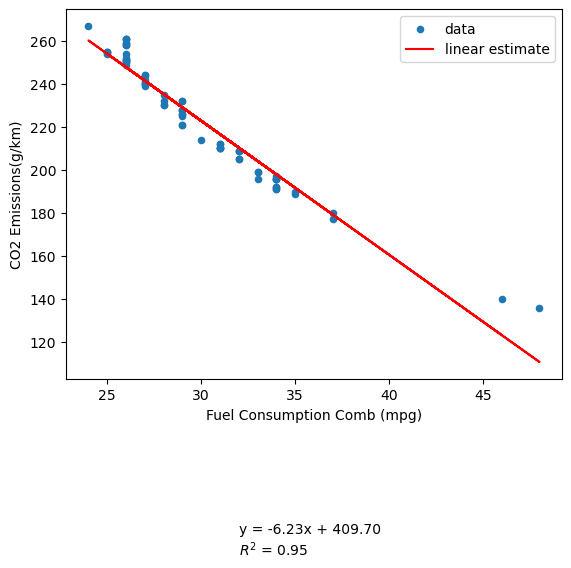

In [23]:
fuel_cost_estimated = df_without_nan['Fuel Consumption Comb (mpg)']*res.slope + res.intercept
fuel_cost_estimated

import matplotlib.pyplot as plt
df_acura.plot(kind = 'scatter', x='Fuel Consumption Comb (mpg)',y='CO2 Emissions(g/km)')
plt.plot( df_without_nan['Fuel Consumption Comb (mpg)'], fuel_cost_estimated, 'r')
plt.legend(['data', 'linear estimate'])
plt.text(32,21, f'y = {res.slope:.2f}x + {res.intercept:.2f}\n$R^2$ = {(res.rvalue)**2:.2f}')

PearsonRResult(statistic=np.float64(1.0), pvalue=np.float64(0.0))


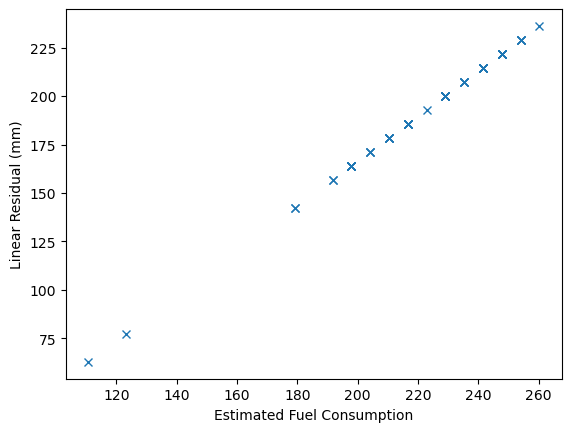

In [30]:
#residuals
residuals = fuel_cost_estimated - df_without_nan['Fuel Consumption Comb (mpg)'] 

plt.plot(fuel_cost_estimated, residuals,  'x')
plt.ylabel('Linear Residual (mm)')
plt.xlabel('Estimated Fuel Consumption')

print(stats.pearsonr(residuals,fuel_cost_estimated))

(array([ 2.,  0.,  0.,  0.,  2., 11.,  8., 17., 12., 20.]),
 array([ 62.78117579,  80.12693275,  97.4726897 , 114.81844665,
        132.1642036 , 149.50996056, 166.85571751, 184.20147446,
        201.54723141, 218.89298837, 236.23874532]),
 <BarContainer object of 10 artists>)

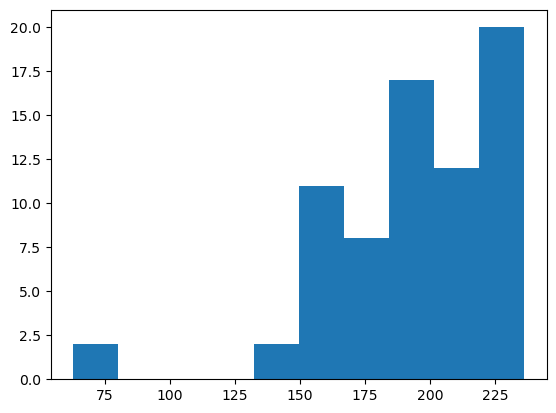

In [31]:
plt.hist(residuals)

In [39]:
# We drop all rows with missing values, because the linear regression function does not work with missing values.
df_acura = df_acura.groupby(Vehicle Class)

SyntaxError: invalid syntax (741099827.py, line 2)